---
downloads: []
---

# Modelos estocasticos de Markov


Los **modelos de Markov** son modelos estocásticos utilizados para describir sistemas que evolucionan en el tiempo mediante transiciones aleatorias entre diferentes estados. Su característica fundamental es que la probabilidad del estado futuro depende del estado actual, sin requerir información completa sobre la trayectoria anterior.

En este capítulo introduciremos el concepto de **proceso estocástico**, mediante el cual podemos representar matemáticamente la evolución aleatoria de un sistema a lo largo del tiempo. A partir de esta idea, construiremos las **cadenas de Markov**, una clase particular de procesos estocásticos que satisface la propiedad de Markov.

Estudiaremos la construcción e interpretación de la matriz de transición y la distribución inicial. Posteriormente analizaremos la evolución de las distribuciones de probabilidad, la simulación de trayectorias y su verosimilitud. También estudiaremos el comportamiento de las cadenas a largo plazo.

Finalmente, introduciremos las **cadenas de Markov ocultas**, en las cuales los estados del sistema no pueden observarse directamente y deben inferirse a partir de observaciones relacionadas probabilísticamente con ellos.



## 1. Introducción

### 1.1. Que es un procesos estocástico

Una variable aleatoria permite describir el resultado de un experimento aleatorio. En muchas situaciones, sin embargo, no estamos interesados en un único resultado, sino en **cómo evoluciona un sistema aleatorio a lo largo del tiempo**. Para estudiar este tipo de fenómenos se utilizan los **procesos estocásticos**.

Un proceso estocástico es una familia de variables aleatorias

$$
\{X_t\}_{t\in T},
$$

donde $T$ es el conjunto de índices que representa el tiempo u otro parámetro. La variable aleatoria $X_t$ describe el estado del sistema en el instante $t$.

Si

$$
T=\{0,1,2,\ldots\},
$$

se tiene un **proceso en tiempo discreto**. Si

$$
T=[0,\infty),
$$

se tiene un **proceso en tiempo continuo**.

En este capítulo nos concentraremos en procesos en **tiempo discreto** y, en particular, en aquellos que satisfacen la propiedad de Markov.

### 1.2. Trayectorias de un proceso estocástico

Una **trayectoria** o **realización** de un proceso estocástico corresponde a una secuencia particular de valores que puede tomar el proceso. Para un proceso en tiempo discreto, una trayectoria puede escribirse como

$$
x_0,x_1,x_2,\ldots
$$

y corresponde a una realización concreta

$$
X_0=x_0,\qquad
X_1=x_1,\qquad
X_2=x_2,\ldots
$$

Es importante distinguir entre el proceso estocástico y una trayectoria. El proceso describe el comportamiento probabilístico del sistema, mientras que una trayectoria representa una de las posibles evoluciones que puede observarse.


*#### Ejemplo

Supongamos que $X_t$ representa el estado del clima durante el día $t$, con tres posibles estados:

$$
S=\text{soleado},\qquad
N=\text{nublado},\qquad
L=\text{lluvioso}.
$$

Una posible trayectoria es

$$
S,S,N,L,L,N,S,\ldots
$$

mientras que otra podría ser

$$
L,N,N,S,S,S,N,\ldots
$$

Ambas son realizaciones posibles del mismo proceso. El modelo probabilístico determina las probabilidades asociadas a las diferentes evoluciones del sistema.





## 2. Cadenas de Markov


### 2.1 Definicion y propiedades

Las **cadenas de Markov** son un tipo de proceso estocástico que posee la llamada **propiedad de Markov**. Esta propiedad establece que, conocido el estado presente del sistema, la distribución de probabilidad del estado futuro no depende de los estados anteriores.

En términos informales, se dice que una cadena de Markov **no tiene memoria**: para determinar probabilísticamente qué ocurrirá en el siguiente instante solo es necesario conocer el estado actual.

Esta propiedad puede expresarse mediante la siguiente igualdad:

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t,X_{t-1}=x_{t-1},\ldots,X_0=x_0)
=
P(X_{t+1}=x_{t+1}\mid X_t=x_t).
$$

#### **Notación**

La expresión

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t,X_{t-1}=x_{t-1},\ldots,X_0=x_0)
$$

denota la probabilidad condicional de que el proceso pase al estado $x_{t+1}$ en el tiempo $t+1$, dado que se conocen los estados que ha ocupado anteriormente.

En particular,

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t)
$$

representa la probabilidad de que el proceso pase al estado $x_{t+1}$ en el tiempo $t+1$, dado que se encuentra en el estado $x_t$ en el tiempo $t$.


#### **Definición**

Una **cadena de Markov** es una colección de variables aleatorias $\{X_t\}_{t\in T}$ que satisface la propiedad de Markov:

$$
P(X_{t+1}=x_{t+1}\mid X_t=x_t,X_{t-1}=x_{t-1},\ldots,X_0=x_0)
=
P(X_{t+1}=x_{t+1}\mid X_t=x_t).
$$

Esto significa que el estado futuro $X_{t+1}$ depende probabilísticamente únicamente del estado presente $X_t$ y es independiente de los estados anteriores $X_{t-1},\ldots,X_0$.


#### **Clasificación de las cadenas de Markov**

Las cadenas de Markov pueden clasificarse según la forma en que se considera el tiempo.

- **Cadenas de Markov en tiempo discreto**

  - Los estados del proceso cambian en pasos discretos de tiempo.
  - Se representan mediante una **matriz de transición** $P$.
  - El elemento $P_{ij}$ representa la probabilidad de pasar del estado $i$ al estado $j$ en un solo paso de tiempo.

- **Procesos de Markov en tiempo continuo**

  - El proceso puede cambiar en cualquier instante del tiempo.
  - Se utilizan matrices de tasas de transición, usualmente denotadas por $Q$.
  - El elemento $Q_{ij}$ representa una tasa asociada con la transición del estado $i$ al estado $j$.

En este curso solo trabajaremos con cadenas de Markov de tipo discreto.  A su vez, las cadenas de Markov pueden clasificarse según si sus probabilidades de transición dependen del tiempo:

- **Cadena de Markov homogénea:** las probabilidades de transición son constantes en el tiempo. En este caso,

  $$
  P(X_{t+1}=j\mid X_t=i)=P_{ij}
  $$

  para todo $t$.

- **Cadena de Markov no homogénea:** las probabilidades de transición pueden variar con el tiempo.



### 2.2. El Vector de estado

Para describir la evolución de una cadena de Markov no basta con conocer cuáles son los estados posibles del sistema. También necesitamos conocer cómo se distribuye la probabilidad entre esos estados en cada instante de tiempo. El vector de estado permite representar esta información de manera compacta. Así, en lugar de indicar por separado la probabilidad de encontrarse en cada estado, podemos reunir todas estas probabilidades en un único vector.

Supongamos que un sistema puede encontrarse en $n$ estados posibles,

$$
x_1,x_2,\ldots,x_n.
$$

Si $X_t$ representa el estado del sistema en el tiempo $t$, definimos el **vector de estado** como

$$
\mathbf{v}_t=
(v_{t,1},v_{t,2},\ldots,v_{t,n}),
$$

donde

$$
v_{t,i}=P(X_t=x_i),
\qquad i=1,\ldots,n.
$$

Por tanto,

$$
\mathbf{v}_t=
\big(
P(X_t=x_1),
P(X_t=x_2),
\ldots,
P(X_t=x_n)
\big).
$$

El vector de estado es, entonces, un **vector de probabilidades** que describe la distribución del sistema entre los diferentes estados en el tiempo $t$. Como se trata de una distribución de probabilidad, sus componentes satisfacen

$$
v_{t,i}\geq 0,
\qquad i=1,\ldots,n,
$$

y

$$
\sum_{i=1}^{n}v_{t,i}=1.
$$

Por ejemplo, si un sistema tiene tres estados y

$$
\mathbf{v}_t=(0.2,0.5,0.3),
$$

entonces

$$
P(X_t=x_1)=0.2,\qquad
P(X_t=x_2)=0.5,\qquad
P(X_t=x_3)=0.3.
$$

Así, el vector de estado resume la distribución de probabilidad del sistema en un instante determinado.



### 2.3. La matriz de transición en un proceso de Markov

En una cadena de Markov en tiempo discreto, la **matriz de transición** $P$ permite representar las probabilidades de transición entre los estados del sistema en un intervalo de tiempo.

Sea $\{X_t\}_{t\geq 0}$ una cadena de Markov con espacio de estados

$$
S=\{1,2,\ldots,n\}.
$$

La matriz de transición $P$ es una matriz cuadrada de dimensión $n\times n$ cuyos elementos están definidos por

$$
P_{ij}
=
P(X_{t+1}=j\mid X_t=i),
\qquad i,j=1,\ldots,n.
$$

Por tanto,

$$
P=
\begin{pmatrix}
P_{11} & P_{12} & \cdots & P_{1n}\\
P_{21} & P_{22} & \cdots & P_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
P_{n1} & P_{n2} & \cdots & P_{nn}
\end{pmatrix}.
$$

El elemento $P_{ij}$ representa la probabilidad de que el sistema se encuentre en el estado $j$ en el siguiente instante, dado que en el instante actual se encuentra en el estado $i$.

Como cada fila representa una distribución de probabilidad sobre los posibles estados siguientes, se debe cumplir

$$
P_{ij}\geq 0
$$

y

$$
\sum_{j=1}^{n}P_{ij}=1,
\qquad i=1,\ldots,n.
$$

Una matriz que satisface estas condiciones se denomina **matriz estocástica**.

Por ejemplo, para una cadena con tres estados, consideremos

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix}.
$$

Si el sistema se encuentra actualmente en el estado $1$, la primera fila indica que las probabilidades de pasar, respectivamente, a los estados $1$, $2$ y $3$ son $0.7$, $0.2$ y $0.1$.

En una **cadena de Markov homogénea**, las probabilidades de transición no dependen del instante $t$. En consecuencia, la misma matriz $P$ describe las transiciones en cada paso de tiempo:

$$
P(X_{t+1}=j\mid X_t=i)=P_{ij}.
$$

La matriz de transición constituye, por tanto, el elemento fundamental para describir la evolución probabilística de la cadena y determinar la distribución de los estados en instantes posteriores.



## 3. Evolución del vector de estado

### 3.1. Multiplicacion vector por matriz

La matriz de transición permite determinar cómo evoluciona el vector de estado de una cadena de Markov.

Supongamos que la cadena tiene $n$ estados y que utilizamos vectores de estado como **vectores fila**. Escribimos

$$
\mathbf{v}_t=
\begin{pmatrix}
v_{t,1},\,
v_{t,2},\,
\ldots,\,
v_{t,n}
\end{pmatrix},
$$

donde

$$
v_{t,i}=P(X_t=x_i).
$$

La matriz de transición es

$$
P=
\begin{pmatrix}
p_{11} & p_{12} & \cdots & p_{1n}\\
p_{21} & p_{22} & \cdots & p_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
p_{n1} & p_{n2} & \cdots & p_{nn}
\end{pmatrix},
$$

donde $p_{ij}$ representa la probabilidad de pasar del estado $x_i$ al estado $x_j$ en un paso.

El vector de estado en el siguiente instante se obtiene mediante el producto

$$
\boxed{\mathbf{v}_{t+1}=\mathbf{v}_tP}.
$$

Esta multiplicación puede interpretarse como una colección de **productos punto** entre el vector de estado y las columnas de la matriz de transición. En particular,

$$
\mathbf{v}_{t+1}
=
\begin{pmatrix}
v_{t,1},\ldots,v_{t,n}
\end{pmatrix}
P
$$

produce el vector

$$
\mathbf{v}_{t+1}
=
\begin{pmatrix}
\displaystyle\sum_{i=1}^n v_{t,i}p_{i1},
\,
\displaystyle\sum_{i=1}^n v_{t,i}p_{i2},
\,
\ldots,
\,
\displaystyle\sum_{i=1}^n v_{t,i}p_{in}
\end{pmatrix}.
$$

Así, cada componente del nuevo vector se obtiene mediante un producto punto:

$$
v_{t+1,j}
=
\mathbf{v}_t\cdot
\begin{pmatrix}
p_{1j}\\
p_{2j}\\
\vdots\\
p_{nj}
\end{pmatrix}.
$$

Aplicando sucesivamente esta operación,

$$
\mathbf{v}_2=\mathbf{v}_1P
=\mathbf{v}_0P^2,
$$

y, en general,

$$
\boxed{\mathbf{v}_t=\mathbf{v}_0P^t}.
$$

De esta manera, la evolución de una cadena de Markov consiste en aplicar repetidamente la misma transformación al vector de estado.


* #### Ejemplo: evolución del clima

Consideremos un modelo sencillo para el clima de una región. El sistema puede encontrarse en tres estados:

$$
S=\text{soleado},\qquad
N=\text{nublado},\qquad
L=\text{lluvioso}.
$$

Supongamos que el clima del día siguiente depende únicamente del clima del día actual y que la matriz de transición es

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.4 & 0.3\\
0.2 & 0.3 & 0.5
\end{pmatrix}.
$$

Las filas representan el estado actual y las columnas el estado del día siguiente. Supongamos además que el día inicial es soleado. Entonces,

$$
\mathbf{v}_0=(1,0,0).
$$

Utilizando

$$
\mathbf{v}_{t+1}=\mathbf{v}_tP,
$$

obtenemos sucesivamente los vectores de estado. Por ejemplo,

$$
\mathbf{v}_1
=
(1,0,0)
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.4 & 0.3\\
0.2 & 0.3 & 0.5
\end{pmatrix}
=
(0.7,0.2,0.1).
$$

Para el segundo día,

$$
\mathbf{v}_2
=
(0.7,0.2,0.1)P
=
(0.57,0.25,0.18).
$$

A partir de aquí podemos continuar el mismo procedimiento durante un número determinado de días.


### 3.2 Algoritmo para calcular la evolución

El procedimiento puede resumirse en los siguientes pasos:

1. Definir la matriz de transición $P$.
2. Definir el vector de estado inicial $\mathbf{v}_0$.
3. Elegir el número de pasos de tiempo.
4. Calcular $\mathbf{v}_{t+1}=\mathbf{v}_tP$.
5. Guardar cada vector de estado.
6. Repetir los pasos 4 y 5 hasta alcanzar el número de pasos establecido.
7. Representar gráficamente la evolución de cada componente del vector de estado.




### 3.3. Simulacion para evolucionar de los estados  


Cuando se desea estudiar la evolución de una cadena de Markov durante muchos pasos de tiempo, realizar las multiplicaciones sucesivas de forma manual puede resultar dispendioso y poco práctico. Por esta razón, recurriremos a la simulación numérica con Python para automatizar el cálculo de los vectores de estado y estudiar de manera eficiente la evolución del sistema durante un número arbitrario de pasos. Además, la representación gráfica de los resultados facilita identificar patrones y comportamientos que pueden no ser evidentes a partir de unos pocos cálculos.

A continuacion realizamos mostramos una posible implementacion en python de este proceso para el ejemplo del clima considerado en la subseccion 3.1.  


* #### Ejemplo: evolucion del modelo de clima numericamente


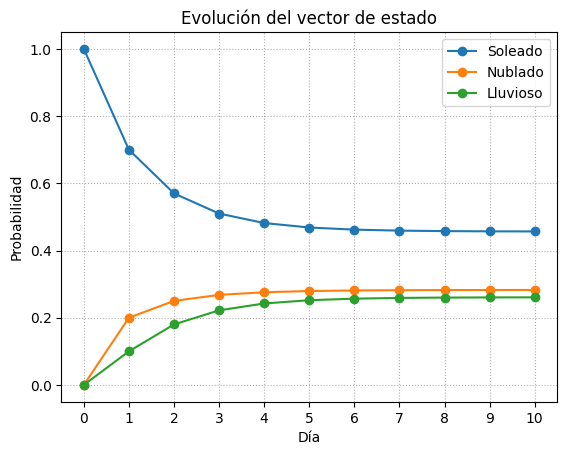

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.4, 0.3],
    [0.2, 0.3, 0.5]
])

# Vector de estado inicial
v = np.array([1.0, 0.0, 0.0])

# Número de días
dias = 10

# Guardar los vectores de estado
estados = [v]

for _ in range(dias):
    v = v @ P
    estados.append(v)

estados = np.array(estados)

# Visualización
plt.plot(estados[:, 0], marker="o", label="Soleado")
plt.plot(estados[:, 1], marker="o", label="Nublado")
plt.plot(estados[:, 2], marker="o", label="Lluvioso")

plt.xlabel("Día")
plt.ylabel("Probabilidad")
plt.title("Evolución del vector de estado")
plt.xticks(range(dias + 1))
plt.grid(linestyle=":")
plt.legend()
plt.show()

Note que en el código se uso la expresión

```python
v = v @ P
```

la cual sirve para implementar precisamente la operación del producto vector por matriz:

$$
\mathbf{v}_{t+1}=\mathbf{v}_t   P
$$

Esta es la operacion que consume mas tiempo de nuestra simulación. La gráfica permite observar cómo cambian las probabilidades de los tres estados a medida que transcurre el tiempo.





* #### Ejemplo: dinámica de una población

Consideremos ahora un ecosistema con tres posibles estados para una población de organismos:

- **Abundante (A):** población alta.
- **Moderada (M):** población moderada.
- **Escasa (E):** población baja.

Se han recolectado datos durante varias temporadas para determinar cómo transita la población entre estos estados. La tabla de observaciones es:

| Estado actual $\rightarrow$ estado siguiente | Abundante (A) | Moderada (M) | Escasa (E) |
|---|---:|---:|---:|
| Abundante (A) | 50 | 30 | 20 |
| Moderada (M) | 40 | 50 | 10 |
| Escasa (E) | 30 | 40 | 30 |

A partir de esta información, utilizaremos un modelo de Markov para determinar la distribución de probabilidad de la población después de siete pasos, suponiendo que inicialmente la población es escasa.



##### **Solución**

 1. Cálculo de la matriz de transición:

La probabilidad de transición de un estado $i$ a un estado $j$ se calcula como

$$
P_{ij}
=
\frac{\text{número de transiciones de }i\text{ a }j}
{\text{total de transiciones desde }i}.
$$

Indexemos los estados como:

- Abundante: estado $1$;
- Moderada: estado $2$;
- Escasa: estado $3$.

Para el estado abundante tenemos:

$$
P_{11}
=
\frac{50}{50+30+20}
=0.50,
$$

$$
P_{12}
=
\frac{30}{100}
=0.30,
\qquad
P_{13}
=
\frac{20}{100}
=0.20.
$$

De manera análoga, obtenemos la matriz de transición

$$
P=
\begin{pmatrix}
0.50&0.30&0.20\\
0.40&0.50&0.10\\
0.30&0.40&0.30
\end{pmatrix}.
$$


2. Estado inicial:

Como inicialmente la población es escasa, el vector de estado inicial es

$$
\mathbf{v}_0=(0,0,1).
$$

Después de $7$ pasos,

$$
\mathbf{v}_7=\mathbf{v}_0P^7.
$$



3. Simulacíon

Por tanto, podemos utilizar Python para calcular la evolución de las probabilidades y visualizarla gráficamente.

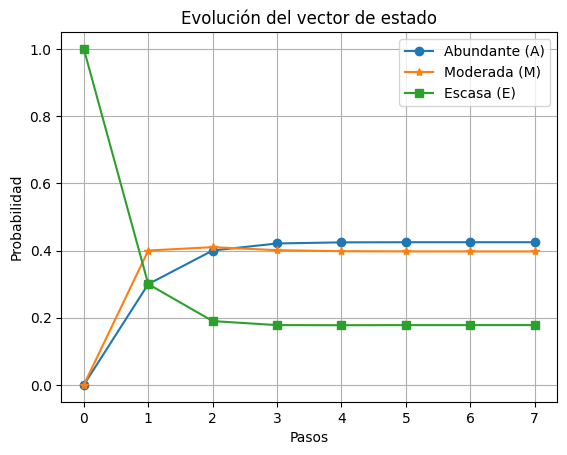

In [9]:

import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.50, 0.30, 0.20],
    [0.40, 0.50, 0.10],
    [0.30, 0.40, 0.30]
])

# Distribución inicial:
# comenzamos en el estado Escasa
v = np.array([0, 0, 1])

# Número de pasos
num_steps = 7

# Guardar la evolución
states = [v]

for _ in range(num_steps):
    v = v @ P
    states.append(v)

states = np.array(states)

plt.plot(states[:, 0], 'o-', label="Abundante (A)")
plt.plot(states[:, 1], '*-', label="Moderada (M)")
plt.plot(states[:, 2],'s-', label="Escasa (E)")

plt.title("Evolución del vector de estado")
plt.xlabel("Pasos")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid()
plt.show()





El código permite observar cómo evolucionan las probabilidades asociadas con los tres estados de la población. La distribución obtenida después de siete pasos permite identificar cuál de los tres estados tiene la mayor probabilidad en ese momento.


## 4. Convergencia de cadenas


### 4.1. Cadenas periódicas
Una cadena de Markov es **periódica** cuando el regreso a un estado solo puede ocurrir después de un número de pasos que es múltiplo de un entero mayor que uno.

Por ejemplo, consideremos

$$
P=
\begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix}.
$$

En esta cadena, el sistema alterna necesariamente entre los dos estados:

$$
0\longrightarrow1\longrightarrow0\longrightarrow1\longrightarrow\cdots
$$

Por tanto, ambos estados tienen período $2$. Si partimos del vector

$$
p_0=
\begin{pmatrix}
0.2 & 0.8
\end{pmatrix},
$$

la evolución

$$
p_{t+1}=p_tP
$$

produce

$$
p_{2k}=
\begin{pmatrix}
0.2 & 0.8
\end{pmatrix},
\qquad
p_{2k+1}=
\begin{pmatrix}
0.8 & 0.2
\end{pmatrix}.
$$

En consecuencia, el vector de estado no converge, sino que oscila entre estas dos distribuciones. Es importante observar que esta cadena  sí posee una distribución estacionaria. En efecto,

$$
\pi=
\begin{pmatrix}
1/2 & 1/2
\end{pmatrix}
$$

satisface

$$
\pi P=\pi.
$$

Así, la existencia de una distribución estacionaria no implica necesariamente que $p_t$ converja hacia ella. En una cadena periódica, las probabilidades pueden continuar oscilando indefinidamente.

A continuación presentamos la simulacion de la evolucion de los estados


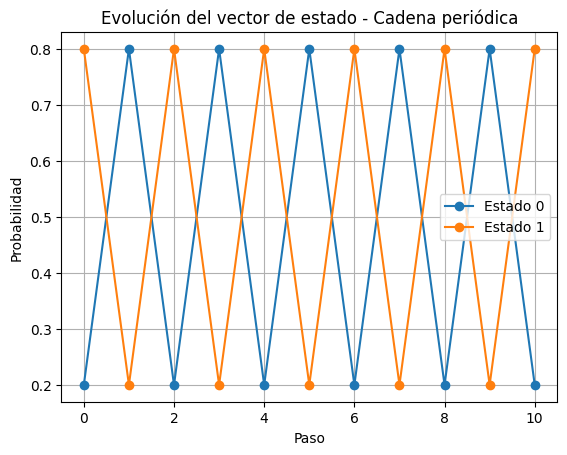

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición periódica
P_periodic = np.array([[0, 1],
                       [1, 0]])

# Vector de estado inicial
p0 = np.array([0.2, 0.8])

# Evolución
n_steps = 10
p = p0
history = [p.copy()]

for _ in range(n_steps):
    p = p @ P_periodic
    history.append(p.copy())

history = np.array(history)

# Graficar evolución
plt.plot(history[:, 0], marker='o', label="Estado 0")
plt.plot(history[:, 1], marker='o', label="Estado 1")

plt.title("Evolución del vector de estado - Cadena periódica")
plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(True)
plt.show()

Note que la función `p.copy()` crea una copia independiente del vector de estado `p` en ese instante. Esto es necesario porque `p` cambia en cada iteración del algoritmo. Al utilizar `p.copy()` al guardar cada estado en `history`, conservamos el vector correspondiente a cada paso sin que sea modificado posteriormente. Así, `history` contiene una copia de cada uno de los vectores de estado de la evolución.




### 4.2. Distribución límite

En una cadena de Markov con matriz de transición $P$, una **distribución límite** es un vector de probabilidades hacia el cual converge la distribución del sistema cuando el número de pasos aumenta. Si el límite existe, se define como

$$
\lambda=\lim_{t\to\infty}\mathbf{p}_0P^t.
$$

En determinadas cadenas, este límite es independiente de la distribución inicial $\mathbf{p}_0$. Es decir, aunque el sistema comience con distribuciones diferentes, después de un número suficientemente grande de pasos las probabilidades se aproximan a los mismos valores.

Consideremos la matriz

$$
P=
\begin{pmatrix}
0.6 & 0.3 & 0.1\\
0.2 & 0.5 & 0.3\\
0.1 & 0.2 & 0.7
\end{pmatrix}.
$$

Supongamos que inicialmente el sistema se encuentra con certeza en el estado $1$:

$$
\mathbf{p}_0=
\begin{pmatrix}
1 & 0 & 0
\end{pmatrix}.
$$

Al aplicar sucesivamente la matriz de transición,

$$
\mathbf{p}_t=\mathbf{p}_0P^t,
$$

las probabilidades evolucionan hasta aproximarse a una distribución límite:

$$
\lambda\approx
\begin{pmatrix}
0.286 & 0.357 & 0.357
\end{pmatrix}.
$$

Por ejemplo, después de un número suficientemente grande de pasos,

$$
\mathbf{p}_t\approx\lambda.
$$


El siguiente código permite observar esta convergencia:


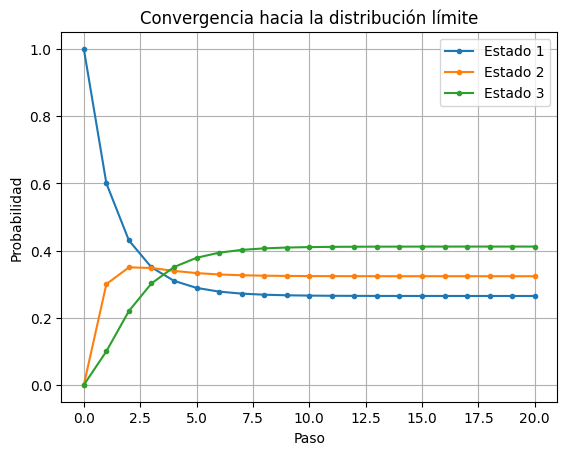

Distribución aproximada después de 20 pasos:
[0.26470829 0.32353041 0.41176131]


In [11]:

import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([[0.6, 0.3, 0.1],
              [0.2, 0.5, 0.3],
              [0.1, 0.2, 0.7]])

# Vector de estado inicial
p = np.array([1.0, 0.0, 0.0])

# Número de pasos
n_steps = 20

# Guardar la evolución
history = [p.copy()]

for _ in range(n_steps):
    p = p @ P
    history.append(p.copy())

history = np.array(history)

# Graficar
plt.plot(history[:, 0], marker='o', markersize=3, label="Estado 1")
plt.plot(history[:, 1], marker='o', markersize=3, label="Estado 2")
plt.plot(history[:, 2], marker='o', markersize=3, label="Estado 3")

plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.title("Convergencia hacia la distribución límite")
plt.legend()
plt.grid(True)
plt.show()

print("Distribución aproximada después de", n_steps, "pasos:")
print(p)


El gráfico muestra cómo las probabilidades de los tres estados se estabilizan progresivamente. En este caso, la distribución límite coincide con la distribución estacionaria $\lambda$, pero los conceptos no son idénticos: una distribución estacionaria es aquella que permanece inalterada al aplicar $P$, mientras que una distribución límite describe el comportamiento al que converge la cadena cuando $t$ aumenta.



## 6. Trayectorias de cadenas de Markov

### 6.1. ¿Que son las trayectorias?

Una **trayectoria** o **camino** de una cadena de Markov es la secuencia de estados que el sistema visita a lo largo del tiempo. Si $\{X_t\}_{t\geq 0}$ representa la cadena, una trayectoria hasta el instante $t$ puede escribirse como

$$
(X_0,X_1,X_2,\ldots,X_t),
$$

donde $X_k$ representa el estado ocupado por el sistema en el instante $k$.

Por ejemplo, una trayectoria de una cadena con tres estados puede ser

$$
(1,2,2,3,1,2,3).
$$

Esta trayectoria representa una **realización particular** de la cadena. En cada paso, el estado siguiente se determina de acuerdo con las probabilidades de transición contenidas en la matriz $P$.

Una forma sencilla de visualizar una trayectoria es representar el tiempo en el eje horizontal y el estado visitado en el eje vertical. Para la trayectoria anterior se obtiene:

```text
Estado
  3 |             ●           ●
  2 |     ●   ●       ●
  1 | ●               ●
    +---------------------------
      0   1   2   3   4   5   6
                  Paso
```


Es importante distinguir entre la **trayectoria** y la **distribución de probabilidad**. La trayectoria muestra una secuencia concreta de estados que puede ocurrir en una realización del proceso, mientras que la distribución describe las probabilidades de encontrar el sistema en cada estado.

Por ejemplo, si una cadena tiene tres estados, una distribución en el instante $t$ puede ser

$$
p_t=(0.2,0.5,0.3),
$$

mientras que una trayectoria posible podría ser

$$
(1,2,2,3,1,2,3).
$$

El estudio de diferentes trayectorias permite analizar mediante simulación propiedades de la cadena, como la frecuencia con que se visitan los estados, la periodicidad y el comportamiento a largo plazo.



* #### Ejemplo: Simulación de una trayectoria

Partimos de un estado inicial y, en cada paso, se selecciona aleatoriamente el siguiente estado utilizando las probabilidades de transición de la matriz $P$.

Sea

$$
\mathbf{v}_0=(1,0,0),
$$

el vector de estado inicial. Esto significa que el sistema comienza con certeza en el estado $0$, es decir,

$$
X_0=0.
$$

Consideremos una cadena de Markov con tres estados y matriz de transición

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix}.
$$


A partir del vector de estado inicial $\mathbf{v}_0=(1,0,0)$, simule una trayectoria de $5$ pasos y determine la secuencia de estados visitados.

Como el sistema comienza en el estado $0$, la primera selección se realiza utilizando la primera fila de $P$:

$$
P_0=(0.7,0.2,0.1).
$$

Por tanto, desde el estado $0$, el sistema permanece en ese estado con probabilidad $0.7$, pasa al estado $1$ con probabilidad $0.2$ y pasa al estado $2$ con probabilidad $0.1$.

Una vez seleccionado el nuevo estado, se utiliza la fila correspondiente de $P$ para determinar el siguiente estado. Este procedimiento se repite hasta completar los $5$ pasos.

En Python:


In [ ]:

import numpy as np

# Matriz de transición
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.1, 0.3, 0.6]
])

# Número de estados
n = 3

# Estado inicial X_0
actual = 0

# Número de pasos
T = 5

# Guardar la trayectoria
trayectoria = [actual]

for t in range(T):

    # Distribución de transición desde el estado actual
    probabilidades = P[actual]

    # Elegir aleatoriamente el siguiente estado
    actual = np.random.choice(n, p=probabilidades)

    trayectoria.append(actual)

print("Trayectoria simulada:")
print(trayectoria)




Una posible ejecución puede producir

```text
Trayectoria simulada:
[0, 0, 1, 1, 2, 1]
```

Esta secuencia representa una posible realización de la cadena:

$$
X_0=0,\quad
X_1=0,\quad
X_2=1,\quad
X_3=1,\quad
X_4=2,\quad
X_5=1.
$$

Por tanto, la trayectoria obtenida es

$$
(X_0,X_1,X_2,X_3,X_4,X_5)
=
(0,0,1,1,2,1).
$$

Es importante notar que esta es solo  una posible trayectori. Al ejecutar nuevamente el programa, puede obtenerse una secuencia diferente, ya que los estados siguientes se seleccionan aleatoriamente de acuerdo con las probabilidades de transición. La simulación permite así generar realizaciones concretas de una cadena de Markov y estudiar experimentalmente su comportamiento.


### 6.2. Verosimilitud de una trayectoria

Una vez definida una trayectoria, podemos preguntarnos  qué tan probable es que la cadena siga exactamente esa secuencia de estados . Esta probabilidad se denomina **verosimilitud de la trayectoria**.

Sea una cadena de Markov con matriz de transición $P$ y vector de estado inicial $\mathbf{v}_0$. Una trayectoria es una secuencia de estados

$$
(X_0,X_1,\ldots,X_n).
$$

La probabilidad de observar exactamente esta trayectoria se obtiene multiplicando la probabilidad del estado inicial por las probabilidades de cada una de las transiciones realizadas:

$$
\mathcal{L}(X_0,X_1,\ldots,X_n)
=
v_0(X_0)
\prod_{t=0}^{n-1}P_{X_t,X_{t+1}},
$$

donde $v_0(X_0)$ es la probabilidad inicial de encontrarse en el estado $X_0$, y $P_{X_t,X_{t+1}}$ es la probabilidad de pasar del estado $X_t$ al estado $X_{t+1}$.

Si el estado inicial está determinado con certeza, entonces $v_0(X_0)=1$ y la expresión se reduce a

$$
\mathcal{L}(X_0,X_1,\ldots,X_n)
=
\prod_{t=0}^{n-1}P_{X_t,X_{t+1}}.
$$

* #### Ejemplo: Verosimilitud de dos trayectorias

Consideremos la matriz de transición

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix},
$$

donde los estados son $1$, $2$ y $3$.

Supongamos que comenzamos en el estado $1$ y observamos la trayectoria

$$
(1,2,2,3,1).
$$

Como el estado inicial es conocido, su probabilidad es $1$. La trayectoria contiene las siguientes transiciones:

$$
1\rightarrow2,\qquad
2\rightarrow2,\qquad
2\rightarrow3,\qquad
3\rightarrow1.
$$

Por lo tanto, su verosimilitud es

$$
\begin{aligned}
\mathcal{L}
&=P_{12}P_{22}P_{23}P_{31}\\
&=(0.2)(0.5)(0.2)(0.1)\\
&=0.002.
\end{aligned}
$$

Así, la probabilidad de que la cadena siga exactamente esta trayectoria es

$$
\boxed{\mathcal{L}=0.002}.
$$

La verosimilitud permite también **comparar diferentes trayectorias**. Dos trayectorias pueden comenzar en el mismo estado, pero tener probabilidades diferentes debido a las transiciones que realizan. Una trayectoria que utiliza transiciones con probabilidades altas tendrá, en general, una verosimilitud mayor que otra que utilice transiciones menos probables.

Por ejemplo, podemos comparar dos trayectorias que parten del estado $1$:

$$
T_1=(1,2,2,3,1)
$$

y

$$
T_2=(1,1,2,3,1).
$$

Sus verosimilitudes son

$$
\mathcal{L}(T_1)
=
(0.2)(0.5)(0.2)(0.1)
=
0.002,
$$

y

$$
\mathcal{L}(T_2)
=
(0.7)(0.2)(0.2)(0.1)
=
0.0028.
$$

En este caso, la segunda trayectoria tiene una probabilidad mayor debido a que incluye la transición $1\rightarrow1$, cuya probabilidad es $0.7$.





La verosimilitud es especialmente útil cuando se dispone de  datos observados. Si se observan muchas trayectorias de un sistema, sus probabilidades pueden utilizarse para estudiar qué tan compatibles son con una determinada matriz de transición y, posteriormente, para estimar los parámetros del modelo.

### 6.3. ¿Cómo encontrar la trayectoria más probable?

Una vez definida la verosimilitud de una trayectoria, podemos preguntarnos cuál es la **trayectoria más probable** entre todas las trayectorias posibles.

Supongamos que conocemos el vector de estado inicial $\mathbf{v}_0$ y la matriz de transición $P$, y queremos encontrar la trayectoria más probable durante $T$ pasos. El problema consiste en encontrar la secuencia

$$
(X_0,X_1,\ldots,X_T)
$$

que maximiza su probabilidad:

$$
\mathcal{L}(X_0,X_1,\ldots,X_T)
=
v_0(X_0)
\prod_{t=0}^{T-1}P_{X_t,X_{t+1}}.
$$

En otras palabras, debemos comparar las trayectorias posibles y seleccionar aquella que tenga la mayor verosimilitud.

Para una cadena pequeña podemos hacer esto mediante **enumeración**. Por ejemplo, consideremos tres estados,

$$
S=\{0,1,2\},
$$

y la matriz

$$
P=
\begin{pmatrix}
0.7 & 0.2 & 0.1\\
0.3 & 0.5 & 0.2\\
0.1 & 0.3 & 0.6
\end{pmatrix},
$$

con vector de estado inicial

$$
\mathbf{v}_0=(1,0,0).
$$

Supongamos que queremos encontrar la trayectoria más probable durante $T=3$ pasos.

Como el sistema comienza en el estado $0$, podemos generar todas las trayectorias posibles de la forma

$$
(0,X_1,X_2,X_3).
$$

Para cada trayectoria calculamos su verosimilitud y finalmente seleccionamos la de mayor valor.

En Python podemos utilizar `itertools.product` para generar todas las posibilidades:




Trayectoria más probable:
(np.int64(1), 0, 0, 0)
Verosimilitud:
0.147


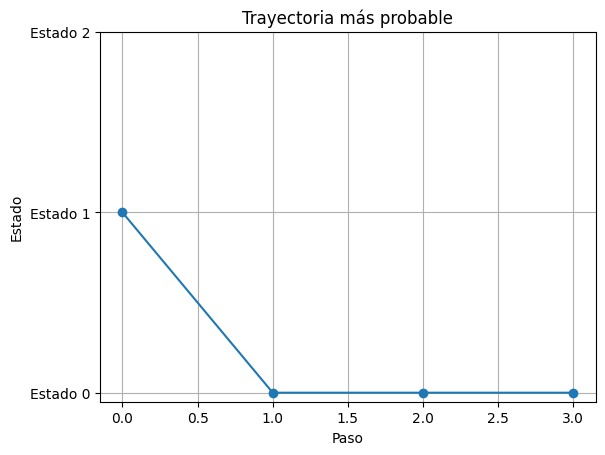

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Matriz de transición
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.1, 0.3, 0.6]
])

# Vector de estado inicial
v0 = np.array([0,1,0])

# Número de estados y pasos
n = 3
T = 3

# Estado inicial
estado_inicial = np.argmax(v0)

# Mejor trayectoria encontrada
mejor_trayectoria = None
mejor_verosimilitud = -1

# Generar todas las trayectorias posibles
for resto in product(range(n), repeat=T):

    trayectoria = (estado_inicial,) + resto

    # Probabilidad del estado inicial
    verosimilitud = v0[trayectoria[0]]

    # Multiplicar las probabilidades de transición
    for t in range(T):
        i = trayectoria[t]
        j = trayectoria[t + 1]

        verosimilitud *= P[i, j]

    # Actualizar la mejor trayectoria
    if verosimilitud > mejor_verosimilitud:
        mejor_verosimilitud = verosimilitud
        mejor_trayectoria = trayectoria

print("Trayectoria más probable:")
print(mejor_trayectoria)

print("Verosimilitud:")
print(mejor_verosimilitud)

# Graficar la trayectoria más probable
tiempo = range(T + 1)

plt.plot(
    tiempo,
    mejor_trayectoria,
    marker="o"
)

plt.yticks([0, 1, 2], ["Estado 0", "Estado 1", "Estado 2"])
plt.xlabel("Paso")
plt.ylabel("Estado")
plt.title("Trayectoria más probable")
plt.grid()
plt.show()




La trayectoria se representa como una secuencia de estados a lo largo del tiempo. En este caso, el programa examina todas las trayectorias posibles de longitud \(T\), calcula la probabilidad de cada una y selecciona aquella con mayor probabilidad. La gráfica permite visualizar directamente la trayectoria seleccionada.




Para este ejemplo, la trayectoria más probable resulta ser

$$
(0,0,0,0),
$$

con verosimilitud

$$
\mathcal{L}
=
(1)(0.7)(0.7)(0.7)
=
0.343.
$$

Esto significa que, entre todas las trayectorias que comienzan en el estado $0$ y tienen tres pasos, esta trayectoria tiene la mayor probabilidad.

La enumeración funciona bien para cadenas pequeñas, pero el número de trayectorias crece rápidamente con el número de estados y pasos. Si existen $n$ estados y se consideran $T$ pasos con un estado inicial fijo, hay

$$
n^T
$$

trayectorias posibles. Por esta razón, para problemas más grandes se utilizan algoritmos más eficientes, como el **algoritmo de Viterbi**, que permite encontrar la trayectoria más probable sin tener que enumerar todas las posibilidades.


### 6.3. ¿Cómo encontrar la trayectoria más probable?

Una vez definida la verosimilitud de una trayectoria, podemos preguntarnos cuál es la **trayectoria más probable** entre todas las trayectorias posibles.

Supongamos que conocemos el vector de estado inicial $\mathbf{v}_0$ y la matriz de transición $P$, y queremos encontrar la trayectoria más probable durante $T$ pasos. El problema consiste en encontrar la secuencia

$$
(X_0,X_1,\ldots,X_T)
$$

que maximiza su probabilidad:

$$
\mathcal{L}(X_0,X_1,\ldots,X_T)
=
v_0(X_0)
\prod_{t=0}^{T-1}P_{X_t,X_{t+1}}.
$$

En otras palabras, debemos considerar las trayectorias posibles, calcular la verosimilitud de cada una y seleccionar aquella que tenga el mayor valor. Para una cadena pequeña podemos hacer esto mediante **enumeración**.


* #### Ejemplo de implementación

Consideremos tres estados numerados,

$$
S=\{0,1,2\},
$$

con la matriz de transicion dado por

$$
P=
\begin{pmatrix}
0.6&0.3&0.1\\
0.1&0.2&0.7\\
0.1&0.2&0.7
\end{pmatrix},
$$

y con vector de estado inicial

$$
\mathbf{v}_0=(0,1,0).
$$

El sistema comienza en el estado $1$. Supongamos que queremos encontrar la trayectoria más probable durante $T=3$ pasos. Como el estado inicial está determinado, las trayectorias posibles tienen la forma

$$
(1,X_1,X_2,X_3).
$$

Para cada trayectoria calculamos su verosimilitud y las comparamos. En Python podemos utilizar `itertools.product` para generar todas las posibilidades:


Trayectoria más probable:
(1, 2, 2, 2)
Verosimilitud:
0.3429999999999999


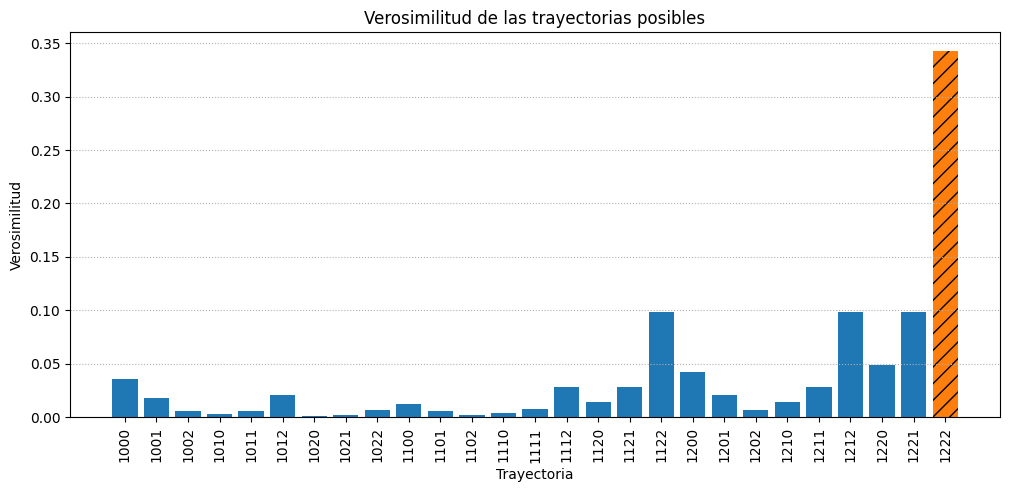

In [31]:

import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.6, 0.3, 0.1],
    [0.1, 0.2, 0.7],
    [0.1, 0.2, 0.7]
])

# Vector de estado inicial
v0 = np.array([0, 1, 0])

# Guardar trayectorias y verosimilitudes
trayectorias = []
verosimilitudes = []

# Mejor trayectoria encontrada
mejor_trayectoria = None
mejor_verosimilitud = 0

# Generar todas las trayectorias posibles
for x1 in range(3):
    for x2 in range(3):
        for x3 in range(3):

            trayectoria = (1, x1, x2, x3)

            # Calcular la verosimilitud
            verosimilitud = (
                P[1, x1] *
                P[x1, x2] *
                P[x2, x3]
            )

            # Guardar los resultados
            trayectorias.append(trayectoria)
            verosimilitudes.append(verosimilitud)

            # Comparar con la mejor trayectoria encontrada
            if verosimilitud > mejor_verosimilitud:
                mejor_verosimilitud = verosimilitud
                mejor_trayectoria = trayectoria

# Mostrar la trayectoria más probable
print("Trayectoria más probable:")
print(mejor_trayectoria)

print("Verosimilitud:")
print(mejor_verosimilitud)

# Crear etiquetas para las trayectorias
etiquetas = []

for trayectoria in trayectorias:
    etiqueta = ""
    for estado in trayectoria:
        etiqueta = etiqueta + str(estado)
    etiquetas.append(etiqueta)

# Encontrar la posición de la mejor trayectoria
posicion_mejor = verosimilitudes.index(mejor_verosimilitud)

# Gráfico de las verosimilitudes
plt.bar(etiquetas, verosimilitudes)

# Resaltar la trayectoria más probable
plt.bar(
    posicion_mejor,
    mejor_verosimilitud,
    hatch="//"
)

plt.xlabel("Trayectoria")
plt.ylabel("Verosimilitud")
plt.title("Verosimilitud de las trayectorias posibles")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle=":")

plt.show()


Noet que enel codigo anterior el método `arreglo.index()` permite buscar un elemento dentro de una lista y devuelve la posición en la que se encuentra. Si el elemento no está presente, genera un error. Por tanto, en el código, la instrucción

```python
posicion_mejor = verosimilitudes.index(mejor_verosimilitud)
```

permite obtener el índice de la mejor verosimilitud. Este índice corresponde también a la posición de la trayectoria asociada en la lista `trayectorias`.



## 7. Cadenas de Markov ocultas (opcional)



### 7.1. Elementos básicos

En una cadena de Markov ordinaria, el estado del sistema puede observarse directamente. Sin embargo, en muchos problemas de modelamiento el estado que determina la evolución del sistema **no es observable directamente**. En su lugar, podemos observar ciertas variables o eventos que dependen probabilísticamente de dicho estado.

Una **cadena de Markov oculta** (*Hidden Markov Model*, HMM) es un modelo en el que existe una secuencia de estados que evoluciona de acuerdo con una cadena de Markov, pero estos estados permanecen ocultos. En cada instante de tiempo se obtiene una **observación** que depende probabilísticamente del estado oculto correspondiente.

Denotemos por $X_t$ el estado oculto del sistema y por $Y_t$ la observación en el instante $t$. La evolución puede representarse esquemáticamente como

$$
X_0 \longrightarrow X_1 \longrightarrow X_2 \longrightarrow \cdots
$$

mientras que cada estado genera una observación

$$
Y_0,\qquad Y_1,\qquad Y_2,\qquad \ldots
$$

De esta manera, el modelo establece dos relaciones probabilísticas:

1. El estado siguiente depende del estado actual, de acuerdo con una **matriz de transición** $P$:
   
   $$
   P(X_{t+1}=x_j\mid X_t=x_i)=p_{ij}.
   $$

2. La observación depende del estado oculto correspondiente, de acuerdo con una **matriz de emisión** $B$:
   
   $$
   P(Y_t=y_j\mid X_t=x_i)=b_{ij}.
   $$

Por tanto, una cadena de Markov oculta se caracteriza, en este curso, por tres elementos principales:

- un **vector de estado inicial** $\mathbf{v}_0$, que describe las probabilidades de los estados ocultos en el instante inicial;
- una **matriz de transición** $P$, que describe las probabilidades de pasar de un estado oculto a otro;
- una **matriz de emisión** $B$, que describe las probabilidades de obtener cada observación dependiendo del estado oculto.

La característica fundamental de este modelo es, entonces, que observamos los eventos $Y_t$, pero no observamos directamente los estados $X_t$ que los generan.
   

* #### Ejemplo. Modelo oculto de un mercado bursátil



Supongamos que queremos modelar el comportamiento de una acción durante varias semanas. Consideramos que el mercado puede encontrarse en uno de dos estados:

- $A$: mercado **alcista**.
- $B$: mercado **bajista**.

Estos estados representan el **régimen del mercado** y, en un modelo oculto, no se observan directamente. En cambio, cada día observamos el comportamiento de la acción, que puede clasificarse como:

- $S$: la acción **sube**.
- $D$: la acción **baja**.

Para ilustrar la estimación de las probabilidades del modelo, supongamos que contamos con los siguientes datos históricos, agrupados según el estado del mercado:

| Estado del mercado | Sube ($S$) | Baja ($D$) | Total |
|:------------------:|-----------:|-----------:|------:|
| $A$ | 8 | 2 | 10 |
| $B$ | 3 | 7 | 10 |

La idea es utilizar una **cadena de Markov oculta** para relacionar los estados no observables del mercado con los movimientos observados de la acción. A partir de estos datos podemos estimar, por un lado, las probabilidades de transición entre los estados del mercado y, por otro, las probabilidades de observar una subida o una bajada de la acción en cada estado.

#### Datos observados

Supongamos que durante $20$ días se registraron los siguientes movimientos de la acción:

$$
S,S,D,S,S,S,D,D,S,S,D,D,D,S,D,D,S,S,S,D.
$$

La secuencia observada es, por tanto,

$$
O=(S,S,D,S,S,S,D,D,S,S,D,D,D,S,D,D,S,S,S,D).
$$

Para construir el modelo, primero estimaremos una matriz de transición a partir de una secuencia de estados del mercado obtenida para un período histórico. Supongamos que durante otro período se identificaron los siguientes estados del mercado:

$$
A,A,A,B,B,A,A,B,B,B,A,A,A,B,A,B,B,A,A,B.
$$

Estos estados representan una clasificación histórica del mercado que utilizaremos para estimar cómo cambia de un estado a otro.

#### **Solucion**

##### **1. Matriz de transición**

La matriz de transición describe la probabilidad de que el mercado pase de un estado a otro:

$$
P=
\begin{pmatrix}
P(A\mid A) & P(B\mid A)\\
P(A\mid B) & P(B\mid B)
\end{pmatrix}.
$$

Contamos las transiciones consecutivas de la secuencia histórica.

Desde $A$ se tienen:

* $A\rightarrow A$: $6$ transiciones.
* $A\rightarrow B$: $4$ transiciones.

Por tanto,

$$
P(A\mid A)=\frac{6}{10}=0.60,
\qquad
P(B\mid A)=\frac{4}{10}=0.40.
$$

Desde $B$ se tienen:

* $B\rightarrow A$: $4$ transiciones.
* $B\rightarrow B$: $5$ transiciones.

Entonces,

$$
P(A\mid B)=\frac{4}{9}\approx0.44,
\qquad
P(B\mid B)=\frac{5}{9}\approx0.56.
$$

Así, la matriz de transición estimada es

$$
\boxed{
P=
\begin{pmatrix}
0.60 & 0.40\\
0.44 & 0.56
\end{pmatrix}
}
$$

Cada fila representa el estado actual y cada columna el estado del día siguiente.

##### **2. Matriz de emisión**

Ahora necesitamos relacionar el estado oculto del mercado con el movimiento observado de la acción. La matriz de emisión contiene las probabilidades

$$
P(O_t\mid X_t),
$$

donde $X_t$ es el estado oculto del mercado y $O_t$ es la observación.Consideremos, por ejemplo, los siguientes datos históricos agrupados según el estado del mercado:

| Estado del mercado | Sube ($S$) | Baja ($D$) | Total |
| :----------------: | ---------: | ---------: | ----: |
|         $A$        |          8 |          2 |    10 |
|         $B$        |          3 |          7 |    10 |

En un mercado alcista, la acción subió $8$ de cada $10$ días, mientras que en un mercado bajista subió solamente $3$ de cada $10$ días.

Por tanto,

$$
P(S\mid A)=\frac{8}{10}=0.80,
\qquad
P(D\mid A)=\frac{2}{10}=0.20,
$$

y

$$
P(S\mid B)=\frac{3}{10}=0.30,
\qquad
P(D\mid B)=\frac{7}{10}=0.70.
$$

La matriz de emisión es entonces

$$
\boxed{
E=
\begin{pmatrix}
0.80 & 0.20\\
0.30 & 0.70
\end{pmatrix}
}
$$

donde las filas corresponden a los estados ocultos $A$ y $B$, y las columnas a las observaciones $S$ y $D$.

##### **3. Evolución de los estados ocultos**

Supongamos que inicialmente creemos que el mercado tiene la misma probabilidad de encontrarse en cualquiera de los dos estados:

$$
\pi_0=
\begin{pmatrix}
0.5 & 0.5
\end{pmatrix}.
$$

La matriz de transición permite calcular la distribución del estado del mercado en los días siguientes.

Si no tenemos en cuenta todavía las observaciones de la acción, la evolución viene dada por

$$
\pi_{t+1}=\pi_tP.
$$

Por ejemplo,

$$
\pi_1=
\begin{pmatrix}
0.5 & 0.5
\end{pmatrix}
\begin{pmatrix}
0.60 & 0.40\\
0.44 & 0.56
\end{pmatrix}
=
\begin{pmatrix}
0.52 & 0.48
\end{pmatrix}.
$$

Esto significa que, después de una transición, la probabilidad estimada de estar en un mercado alcista es $0.52$, mientras que la probabilidad de estar en un mercado bajista es $0.48$.

Podemos repetir este procedimiento para obtener la evolución durante varios días.

##### **4. Evolución teniendo en cuenta las observaciones**

En una cadena de Markov oculta podemos incorporar además la información observada. Por ejemplo, si en un determinado día observamos que la acción **subió**, debemos actualizar nuestra estimación sobre el estado oculto.

La matriz de emisión nos indica que

$$
P(S\mid A)=0.80
$$

mientras que

$$
P(S\mid B)=0.30.
$$

Por tanto, observar una subida hace más probable que el mercado se encuentre en el estado $A$.

De manera análoga, observar una caída favorece el estado $B$, pues

$$
P(D\mid A)=0.20,
\qquad
P(D\mid B)=0.70.
$$

Así, las observaciones de la acción proporcionan información indirecta sobre el estado oculto del mercado.

##### **5. Cálculo de la evolución con Python**

El siguiente programa utiliza la matriz de transición y la secuencia observada para calcular la probabilidad de cada estado oculto después de cada observación.



Día | Observación | P(Alcista) | P(Bajista)
  1 |      S      |      0.743 |      0.257
  2 |      S      |      0.772 |      0.228
  3 |      D      |      0.269 |      0.731
  4 |      S      |      0.714 |      0.286
  5 |      S      |      0.768 |      0.232
  6 |      S      |      0.774 |      0.226
  7 |      D      |      0.270 |      0.730
  8 |      D      |      0.211 |      0.789
  9 |      S      |      0.706 |      0.294
 10 |      S      |      0.767 |      0.233
 11 |      D      |      0.269 |      0.731
 12 |      D      |      0.211 |      0.789
 13 |      D      |      0.205 |      0.795
 14 |      S      |      0.705 |      0.295
 15 |      D      |      0.261 |      0.739
 16 |      D      |      0.210 |      0.790
 17 |      S      |      0.706 |      0.294
 18 |      S      |      0.767 |      0.233
 19 |      S      |      0.774 |      0.226
 20 |      D      |      0.270 |      0.730


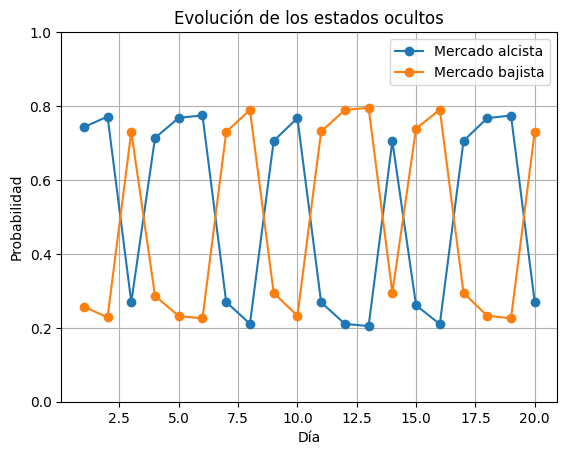


El resultado permite observar cómo las probabilidades de los estados ocultos cambian a medida que se incorporan las observaciones.

Por ejemplo, cuando se observan varios días consecutivos en los que la acción **sube**, aumenta la probabilidad de que el mercado se encuentre en el estado alcista. Por el contrario, una sucesión de días en los que la acción **baja** incrementa la probabilidad asociada al estado bajista. De esta manera, la cadena de Markov oculta permite pasar de una secuencia de observaciones

$$
S,D,S,S,D,\ldots
$$

a una estimación probabilística de los estados no observables

$$
P(X_t=A),\qquad P(X_t=B).
$$

La principal diferencia con una cadena de Markov ordinaria es precisamente que  los estados del sistema no se observan directamente : solamente observamos sus efectos y utilizamos la matriz de emisión para inferir el estado oculto.




### 7.2. Algoritmo de Viterbi

El algoritmo de Viterbi utiliza programación dinámica para encontrar la trayectoria de estados ocultos más probable sin tener que enumerar todas las trayectorias posibles.

Definimos

$$
\delta_t(j)
$$

como la mayor probabilidad conjunta de una trayectoria que termina en el estado $j$ en el instante $t$ y que es compatible con las observaciones realizadas hasta ese instante.

La inicialización es

$$
\delta_0(j)
=
v_0(j)B_{j,Y_0}.
$$

Para cada instante posterior,

$$
\delta_t(j)
=
B_{j,Y_t}
\max_i
\left[
\delta_{t-1}(i)P_{ij}
\right].
$$

Además, guardamos el estado $i$ que produce el máximo. Esto permite reconstruir posteriormente la trayectoria más probable.

Finalmente,

$$
X_T^*
=
\arg\max_j \delta_T(j),
$$

y mediante los estados almacenados anteriormente podemos reconstruir la trayectoria completa.



* #### Ejemplo: Aplicación y verificación del algoritmo de Viterbi

En el ejemplo de la seccion  anterior, clima y uso del paraguas, teniamos dos estados ocultos y cuatro observaciones. Por tanto, el número de trayectorias ocultas posibles es

$$
2^4=16.
$$

Como este número es pequeño, podemos hacer algo que no sería posible para problemas grandes: calcular numericamente la probabilidad de las 16 trayectorias y comprobar cuál es la más probable.


De esta manera, procederemos en dos pasos:

1. Aplicaremos el algoritmo de Viterbi para encontrar numericamente la trayectoria más probable.

2. Calcularemos mediante enumeración la probabilidad de todas las trayectorias posibles y comprobaremos que la trayectoria encontrada por Viterbi es efectivamente la de mayor probabilidad.

De esta forma podemos verificar numericamente el resultado del algoritmo de viterbi aplicado al ejemplo del clima y uso del paraguas.



RESULTADO DE VITERBI
--------------------
Observaciones:
['Paraguas', 'Paraguas', 'No paraguas', 'Paraguas']

Trayectoria más probable:
['Lluvioso', 'Lluvioso', 'Lluvioso', 'Lluvioso']

Probabilidad de la trayectoria:
0.014049280000000004

RESULTADO DE LA ENUMERACIÓN
----------------------------
Trayectoria más probable:
['Lluvioso', 'Lluvioso', 'Lluvioso', 'Lluvioso']

Probabilidad:
0.01404928


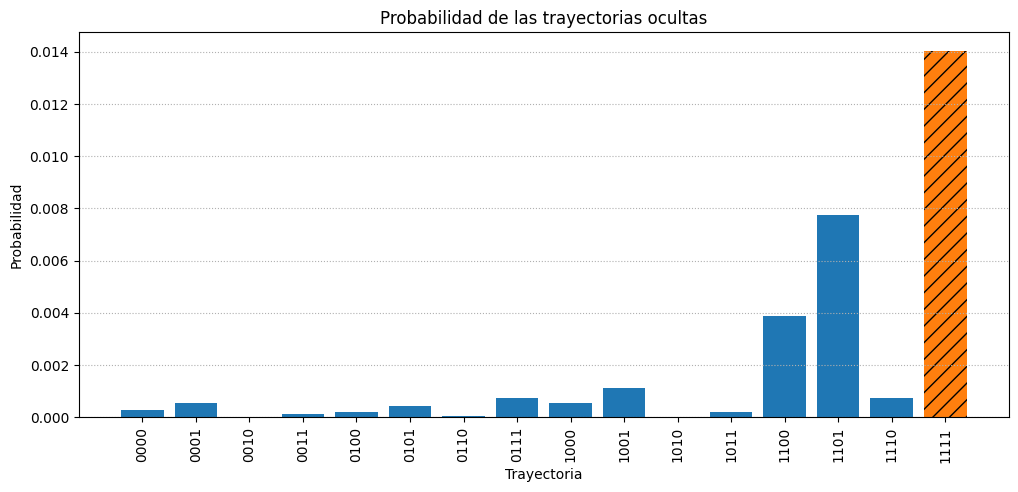


COMPARACIÓN
-----------
Los resultados coinciden.
Viterbi encontró la misma trayectoria
que la búsqueda exhaustiva.


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de transición
P = np.array([
    [0.8, 0.2],
    [0.3, 0.7]
])

# Matriz de emisión
# Columnas: Paraguas, No paraguas
B = np.array([
    [0.1, 0.9],   # Soleado
    [0.8, 0.2]    # Lluvioso
])

# Vector de estado inicial
v0 = np.array([0.6, 0.4])

# Observaciones:
# 0 = Paraguas
# 1 = No paraguas
observaciones = [0, 0, 1, 0]

# Número de estados y observaciones
n_estados = 2
T = len(observaciones)

# Nombres de los estados
nombres = ["Soleado", "Lluvioso"]


# ==========================================================
# 1. ALGORITMO DE VITERBI
# ==========================================================

# Matriz para almacenar las probabilidades de Viterbi
delta = np.zeros((T, n_estados))

# Matriz para almacenar los estados anteriores
psi = np.zeros((T, n_estados), dtype=int)

# Inicialización
delta[0] = v0 * B[:, observaciones[0]]

# Recursión
for t in range(1, T):

    for j in range(n_estados):

        probabilidades = delta[t-1] * P[:, j]

        psi[t, j] = np.argmax(probabilidades)

        delta[t, j] = (
            np.max(probabilidades)
            * B[j, observaciones[t]]
        )

# Estado final más probable
estado_final = np.argmax(delta[T-1])

# Reconstruir la trayectoria
trayectoria_viterbi = [estado_final]

for t in range(T-1, 0, -1):
    estado_final = psi[t, estado_final]
    trayectoria_viterbi.append(estado_final)

trayectoria_viterbi.reverse()

# Mostrar resultado de Viterbi
print("RESULTADO DE VITERBI")
print("--------------------")

print("Observaciones:")
print(["Paraguas", "Paraguas",
       "No paraguas", "Paraguas"])

print("\nTrayectoria más probable:")
print([nombres[i] for i in trayectoria_viterbi])

print("\nProbabilidad de la trayectoria:")
print(delta[T-1, trayectoria_viterbi[-1]])


# ==========================================================
# 2. ENUMERACIÓN DE TODAS LAS TRAYECTORIAS
# ==========================================================

mejor_trayectoria = None
mejor_probabilidad = 0

# Listas para guardar las trayectorias y sus probabilidades
trayectorias = []
probabilidades = []

for x0 in range(n_estados):
    for x1 in range(n_estados):
        for x2 in range(n_estados):
            for x3 in range(n_estados):

                trayectoria = [x0, x1, x2, x3]

                # Probabilidad inicial y primera emisión
                probabilidad = (
                    v0[x0] *
                    B[x0, observaciones[0]]
                )

                # Probabilidades de transición y emisión
                for t in range(1, T):
                    probabilidad *= (
                        P[trayectoria[t-1], trayectoria[t]]
                        * B[trayectoria[t], observaciones[t]]
                    )

                # Guardar los resultados
                trayectorias.append(trayectoria)
                probabilidades.append(probabilidad)

                # Comparar con la mejor trayectoria encontrada
                if probabilidad > mejor_probabilidad:
                    mejor_probabilidad = probabilidad
                    mejor_trayectoria = trayectoria


# ==========================================================
# 3. MOSTRAR EL RESULTADO DE LA ENUMERACIÓN
# ==========================================================

print("\nRESULTADO DE LA ENUMERACIÓN")
print("----------------------------")

print("Trayectoria más probable:")
print([nombres[i] for i in mejor_trayectoria])

print("\nProbabilidad:")
print(mejor_probabilidad)


# ==========================================================
# 4. GRÁFICO DE LAS PROBABILIDADES
# ==========================================================

# Crear etiquetas para las trayectorias
etiquetas = []

for trayectoria in trayectorias:
    etiqueta = ""

    for estado in trayectoria:
        etiqueta += str(estado)

    etiquetas.append(etiqueta)

# Posición de la trayectoria más probable
posicion_mejor = probabilidades.index(mejor_probabilidad)

# Gráfico
plt.figure(figsize=(12, 5))

plt.bar(etiquetas, probabilidades)

# Resaltar la trayectoria más probable
plt.bar(
    posicion_mejor,
    mejor_probabilidad,
    hatch="//"
)

plt.xlabel("Trayectoria")
plt.ylabel("Probabilidad")
plt.title("Probabilidad de las trayectorias ocultas")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle=":")

plt.show()


# ==========================================================
# 5. COMPARACIÓN DE LOS RESULTADOS
# ==========================================================

print("\nCOMPARACIÓN")
print("-----------")

if trayectoria_viterbi == mejor_trayectoria:
    print("Los resultados coinciden.")
    print("Viterbi encontró la misma trayectoria")
    print("que la búsqueda exhaustiva.")
else:
    print("Los resultados no coinciden.")




En este ejemplo, la enumeración permite **comprobar el resultado de Viterbi**: ambos métodos encuentran la misma trayectoria más probable. Sin embargo, la enumeración requiere evaluar todas las trayectorias posibles, cuyo número es

$$
n^T,
$$

donde $n$ es el número de estados y $T$ el número de observaciones. Por ello, cuando $T$ aumenta, la enumeración se vuelve rápidamente costosa y resulta necesario utilizar algoritmos como Viterbi. La trayectoria obtenida representa la secuencia de estados ocultos más probable dadas las observaciones. Así, aunque el clima no se observa directamente, el modelo permite inferir su evolución a partir de las probabilidades de transición y de emisión.





* #### Ejemplo: prediciendo el mercado bursátil

Consideremos una acción cuyo comportamiento está relacionado con el estado general del mercado. Es decir, es una accion de una empresa lider en un cierto sector del mercado. Sin embargo, el estado del mercado no puede observarse directamente. Lo que podemos observar es el comportamiento diario de la acción: si su precio **subió**, **se mantuvo aproximadamente constante** o **bajó**.

Supondremos que el mercado puede encontrarse en uno de tres estados:

- **Alcista**.
- **Constante**.
- **Bajista**.

Estos estados son ocultos, mientras que los movimientos diarios de la acción son observables. La matriz de transición entre los estados del mercado es

$$
P=
\begin{pmatrix}
0.80 & 0.15 & 0.05\\
0.15 & 0.70 & 0.15\\
0.05 & 0.15 & 0.80
\end{pmatrix},
$$

donde el orden de los estados es

$$
(\text{Alcista},\text{Constante},\text{Bajista}).
$$

Por ejemplo,

$$
P_{11}=0.80
$$

significa que, si el mercado se encuentra en un estado alcista, existe una probabilidad de $0.80$ de que continúe alcista al día siguiente.

La matriz de emisión es

$$
B=
\begin{pmatrix}
0.80 & 0.15 & 0.05\\
0.10 & 0.80 & 0.10\\
0.05 & 0.15 & 0.80
\end{pmatrix},
$$

donde las columnas corresponden a las observaciones

$$
(\text{Subió},\text{Constante},\text{Bajó}).
$$

Por ejemplo,

$$
P(\text{Subió}\mid\text{Alcista})=0.80,
$$

mientras que

$$
P(\text{Bajó}\mid\text{Alcista})=0.05.
$$

Supondremos que inicialmente las probabilidades de los tres estados son

$$
\mathbf{v}_0=(0.3,0.4,0.3).
$$

Durante un período de 15 días observamos el siguiente comportamiento de la acción:

| Día | Observación |
|:---:|:---:|
| 1 | Subió |
| 2 | Subió |
| 3 | Subió |
| 4 | Subió |
| 5 | Constante |
| 6 | Constante |
| 7 | Bajó |
| 8 | Bajó |
| 9 | Bajó |
| 10 | Constante |
| 11 | Subió |
| 12 | Subió |
| 13 | Subió |
| 14 | Bajó |
| 15 | Bajó |

Las observaciones muestran varios cambios en el comportamiento de la acción: inicialmente presenta un período de crecimiento, posteriormente se estabiliza, luego atraviesa un período de caída, vuelve a crecer y finalmente vuelve a disminuir.

Nuestro objetivo es utilizar el **algoritmo de Viterbi** para determinar cuál es la trayectoria más probable de los estados ocultos del mercado que pudo haber generado las observaciones anteriores.

La trayectoria obtenida permite interpretar los cambios observados en la acción en términos del estado probable del mercado.

 ##### **1. Formulación matemática**

Denotemos por

$$
X_t\in
\{\text{Alcista},\text{Constante},\text{Bajista}\}
$$

el estado oculto del mercado en el día $t$, y por $Y_t$ la observación correspondiente al comportamiento de la acción.

La cadena de estados ocultos tiene la forma

$$
X_1\longrightarrow X_2\longrightarrow
\cdots\longrightarrow X_{15}.
$$

A partir de las observaciones

$$
Y_1,Y_2,\ldots,Y_{15},
$$

el algoritmo de Viterbi busca la trayectoria que maximiza

$$
P(X_1,X_2,\ldots,X_{15}
\mid
Y_1,Y_2,\ldots,Y_{15}).
$$

En otras palabras, buscamos la secuencia de estados del mercado que sea más probable dadas las observaciones de la acción.

Una vez obtenida la trayectoria más probable, podemos simular la evolución de una acción y del mercado.

Como supuesto ilustrativo, consideraremos que cuando el mercado está **alcista**, la acción aumenta un $3\%$ diario y el mercado aumenta un $1.5\%$. Cuando el mercado está **bajista**, la acción disminuye un $3\%$ diario y el mercado disminuye un $1.5\%$. Finalmente, cuando el mercado está en el estado **constante**, suponemos que ambos permanecen sin cambios.

Por tanto,

$$
S_{t+1}=
\begin{cases}
1.03S_t, & X_t=\text{Alcista},\\
S_t, & X_t=\text{Constante},\\
0.97S_t, & X_t=\text{Bajista},
\end{cases}
$$

mientras que para el mercado tenemos

$$
M_{t+1}=
\begin{cases}
1.015M_t, & X_t=\text{Alcista},\\
M_t, & X_t=\text{Constante},\\
0.985M_t, & X_t=\text{Bajista}.
\end{cases}
$$

Tomaremos como valores iniciales

$$
S_0=M_0=100.
$$

Los porcentajes utilizados son únicamente **supuestos ilustrativos** para construir el ejemplo y visualizar cómo los diferentes estados del mercado pueden producir distintas trayectorias de precios.

##### 2. Implementación en Python

El siguiente código aplica el algoritmo de Viterbi, reconstruye la trayectoria más probable y posteriormente utiliza dicha trayectoria para simular y graficar la evolución de la acción y del mercado durante los 15 días.



La trayectoria obtenida por Viterbi permite relacionar los movimientos observados de la acción con una posible secuencia de estados del mercado. El gráfico final muestra cómo, bajo los supuestos establecidos, los períodos alcistas, constantes y bajistas producen diferentes comportamientos en la acción y en el mercado.



TRAYECTORIA MÁS PROBABLE
------------------------
Día 1 : Alcista
Día 2 : Alcista
Día 3 : Alcista
Día 4 : Alcista
Día 5 : Constante
Día 6 : Constante
Día 7 : Bajista
Día 8 : Bajista
Día 9 : Bajista
Día 10 : Constante
Día 11 : Alcista
Día 12 : Alcista
Día 13 : Alcista
Día 14 : Bajista
Día 15 : Bajista


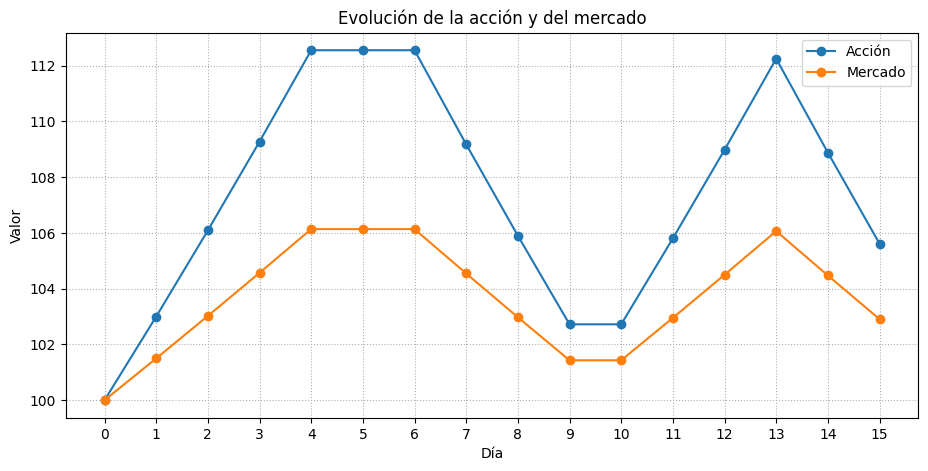

In [54]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# DATOS DEL MODELO
# ==========================================================

# Estados:
# 0 = Alcista
# 1 = Constante
# 2 = Bajista

P = np.array([
    [0.80, 0.15, 0.05],
    [0.15, 0.70, 0.15],
    [0.05, 0.15, 0.80]
])


# ==========================================================
# MATRIZ DE EMISIÓN
# ==========================================================

# Observaciones:
# 0 = Subió
# 1 = Constante
# 2 = Bajó

B = np.array([
    [0.80, 0.15, 0.05],   # Alcista
    [0.10, 0.80, 0.10],   # Constante
    [0.05, 0.15, 0.80]    # Bajista
])


# Vector de estado inicial
v0 = np.array([0.3, 0.4, 0.3])


# Observaciones durante 15 días
observaciones = [0, 0, 0, 0, 1, 1, 2, 2, 2, 1, 0, 0, 0, 2, 2 ]


# Número de estados y días
n_estados = 3
T = len(observaciones)


# Nombres de los estados
nombres = [
    "Alcista",
    "Constante",
    "Bajista"
]


# ==========================================================
# 1. ALGORITMO DE VITERBI
# ==========================================================

# Matriz para almacenar las probabilidades de Viterbi
delta = np.zeros((T, n_estados))

# Matriz para almacenar los estados anteriores
psi = np.zeros((T, n_estados), dtype=int)


# Inicialización
delta[0] = v0 * B[:, observaciones[0]]


# Recursión
for t in range(1, T):

    for j in range(n_estados):

        probabilidades = delta[t-1] * P[:, j]

        psi[t, j] = np.argmax(probabilidades)

        delta[t, j] = (
            np.max(probabilidades)
            * B[j, observaciones[t]]
        )


# Estado final más probable
estado_final = np.argmax(delta[T-1])


# Reconstruir la trayectoria
trayectoria_viterbi = [estado_final]

for t in range(T-1, 0, -1):

    estado_final = psi[t, estado_final]

    trayectoria_viterbi.append(estado_final)


trayectoria_viterbi.reverse()


# Mostrar resultado
print("TRAYECTORIA MÁS PROBABLE")
print("------------------------")

for t in range(T):
    print(
        "Día", t + 1,
        ":", nombres[trayectoria_viterbi[t]]
    )



# ==========================================================
# 2. EVOLUCIÓN DE LA ACCIÓN Y DEL MERCADO
# ==========================================================

# Valores iniciales
accion_inicial = 100
mercado_inicial = 100


# Variaciones diarias
cambio_accion = 0.03
cambio_mercado = 0.015


# Listas para almacenar los valores
accion = [accion_inicial]
mercado = [mercado_inicial]


# Evolución día por día
for estado in trayectoria_viterbi:

    accion_actual = accion[-1]
    mercado_actual = mercado[-1]

    if estado == 0:

        # Mercado alcista
        accion_nueva = accion_actual * 1.03
        mercado_nuevo = mercado_actual * 1.015

    elif estado == 1:

        # Mercado constante
        accion_nueva = accion_actual
        mercado_nuevo = mercado_actual

    else:

        # Mercado bajista
        accion_nueva = accion_actual * 0.97
        mercado_nuevo = mercado_actual * 0.985

    accion.append(accion_nueva)
    mercado.append(mercado_nuevo)


# Días
dias = np.arange(T + 1)


# ==========================================================
# 3. GRÁFICO DE LA EVOLUCIÓN BURSÁTIL
# ==========================================================

plt.figure(figsize=(11, 5))

plt.plot(
    dias,
    accion,
    marker="o",
    label="Acción"
)

plt.plot(
    dias,
    mercado,
    marker="o",
    label="Mercado"
)

plt.xlabel("Día")
plt.ylabel("Valor")
plt.title("Evolución de la acción y del mercado")

plt.xticks(dias)

plt.legend()

plt.grid(linestyle=":")

plt.show()

La trayectoria obtenida por Viterbi permite relacionar los movimientos observados de la acción con una posible secuencia de estados del mercado. El gráfico final muestra cómo, bajo los supuestos establecidos, los períodos alcistas, constantes y bajistas producen diferentes comportamientos en la acción y en el mercado.

 ## Ejercicios

### Ejercicio 1. Probabilidades de transición

Una cadena de Markov tiene tres estados $A$, $B$ y $C$, con matriz de transición

$$
P=
\begin{pmatrix}
0.6&0.3&0.1\\
0.2&0.5&0.3\\
0.1&0.2&0.7
\end{pmatrix}.
$$

Si inicialmente el sistema se encuentra en el estado $A$:

1. Calcule la probabilidad de encontrarse en $B$ después de dos pasos.
2. Calcule la probabilidad de la trayectoria $A\to B\to C$.
3. Calcule la probabilidad de encontrarse en $C$ después de tres pasos.

---

### Ejercicio 2. Trayectorias y verosimilitud

Considere una cadena de Markov con estados $S$ (soleado) y $L$ (lluvioso), cuya matriz de transición es

$$
P=
\begin{pmatrix}
0.8&0.2\\
0.4&0.6
\end{pmatrix}.
$$

1. Calcule la probabilidad de la trayectoria

   $$
   S\to S\to L\to L\to S.
   $$

2. Calcule la probabilidad de la trayectoria

   $$
   S\to L\to S\to L\to S.
   $$

3. Compare las dos trayectorias e indique cuál tiene mayor verosimilitud.

---

### Ejercicio 3. Estimación de la matriz de transición

Durante $20$ días se registra el estado de una máquina, que puede encontrarse en funcionamiento $F$ o en mantenimiento $M$:

$$
F,F,F,M,M,F,F,M,F,F,F,M,M,M,F,F,M,M,F,F.
$$

A partir de estos datos:

1. Construya la matriz de frecuencias de transición.
2. Estime la matriz de transición $P$ mediante frecuencias relativas.
3. Utilice la matriz estimada para calcular la probabilidad de que una máquina que actualmente está en funcionamiento se encuentre en mantenimiento después de dos días.

---

### Ejercicio 4. Distribución de estados después de varios pasos

Una población se clasifica en tres grupos: jóvenes $J$, adultos $A$ y mayores $M$. La matriz de transición es

$$
P=
\begin{pmatrix}
0.5&0.4&0.1\\
0.1&0.7&0.2\\
0.0&0.3&0.7
\end{pmatrix}.
$$

Inicialmente, el $70\%$ de la población es joven, el $20\%$ adulta y el $10\%$ mayor.

1. Determine la distribución de la población después de un paso.
2. Determine la distribución después de tres pasos.
3. ¿Qué ocurre con la distribución cuando aumenta el número de pasos?



### Ejercicio 5. Cadena de Markov oculta y algoritmo de Viterbi

El comportamiento de un mercado puede encontrarse en dos estados ocultos:

$$
A=\text{alcista},\qquad B=\text{bajista}.
$$

La matriz de transición es

$$
P=
\begin{pmatrix}
0.8&0.2\\
0.3&0.7
\end{pmatrix}.
$$

Cada día se observa si una acción sube $(+)$ o baja $(-)$. Las probabilidades de emisión son

| Estado | $+$ | $-$ |
|:---:|:---:|:---:|
| $A$ | $0.8$ | $0.2$ |
| $B$ | $0.3$ | $0.7$ |

Para la secuencia de observaciones

$$
+,+,-,-,+,
$$

determine la trayectoria de estados ocultos más probable utilizando el **algoritmo de Viterbi**.



### Ejercicio 6. Modelo de un mercado bursátil

Durante varias semanas se registra el comportamiento de una acción, clasificando cada día el mercado como **al alza** ($A$), **estable** ($E$) o **a la baja** ($B$). Las observaciones obtenidas son:

$$
A,A,E,A,A,B,E,E,A,B,B,E,A,A,E,B,B,B,E,A,A,E,A,B,E,E,A,A,B,B.
$$

1. A partir de los datos, construya la matriz de frecuencias de transición y estime la matriz de transición $P$ mediante frecuencias relativas.

2. Suponga que actualmente el mercado se encuentra **al alza**. Utilice la matriz $P$ para calcular la distribución de probabilidad del estado del mercado dentro de $30$ días.

3. Simule mediante Python una trayectoria del mercado durante los próximos $30$ días, comenzando en el estado **al alza**.

4. Repita la simulación varias veces y analice la variabilidad de las trayectorias obtenidas.



### Ejercicio 7. Comparación de modelos de Markov ocultos

Se desea modelar el comportamiento de un mercado mediante una cadena de Markov oculta con dos estados:

$$
A=\text{mercado al alza},\qquad
B=\text{mercado a la baja}.
$$

Cada día se observa si una acción sube $(+)$ o baja $(-)$.

Se consideran los siguientes dos modelos.

**Modelo 1**

La matriz de transición es

$$
P_1=
\begin{pmatrix}
0.8&0.2\\
0.3&0.7
\end{pmatrix},
$$

y las probabilidades de emisión son

| Estado | $+$ | $-$ |
|:---:|:---:|:---:|
| $A$ | $0.8$ | $0.2$ |
| $B$ | $0.3$ | $0.7$ |

**Modelo 2**

La matriz de transición es

$$
P_2=
\begin{pmatrix}
0.6&0.4\\
0.4&0.6
\end{pmatrix},
$$

y las probabilidades de emisión son

| Estado | $+$ | $-$ |
|:---:|:---:|:---:|
| $A$ | $0.7$ | $0.3$ |
| $B$ | $0.4$ | $0.6$ |

Considere la secuencia de observaciones

$$
+,-,+,+,-.
$$

Suponga que la probabilidad inicial de cada estado es $0.5$.

1. Calcule la verosimilitud de la secuencia de observaciones bajo cada modelo.

2. Utilice el algoritmo de Viterbi para encontrar la trayectoria de estados ocultos más probable bajo cada modelo.

3. Compare las trayectorias obtenidas y explique cómo las diferencias entre las matrices de transición y de emisión afectan los resultados.
